# Feature Engineering v2: BMS Academic & Temporal Feature Expansion

**Task:** Expand 10-minute library smart meter readings (`library_cleaned_master.csv`) into a rich, deep-learning-ready feature matrix (`library_featured_v2.csv`) for 24-hour ahead energy forecasting.  
**Dataset:** I-BLEND Library Building, IIT Mandi (Feb 2014 – Nov 2017)  
**Target:** Building electrical power consumption (Watts) 24 hours into the future (`target = power(t + 144)`).

---

### Context in University Building Management Systems (BMS)
In modern university BMS architectures (e.g., a 7-floor academic building with automated zone control), power consumption is driven by three coupled dynamics:
1. **Physical Diurnal Cycles:** Natural solar radiation, ambient temperature cycles, and regular operating shifts.
2. **Institutional Academic Calendar:** Scheduled lectures (8:00 AM to 6:00 PM), evening study hours, exam preparation rushes, and vacation shutdowns.
3. **Occupancy & Zone Dynamics:** The physical presence of students across floors, which directly triggers lighting, HVAC chilled water demand, and workstation power.

While baseline tree models (LightGBM, Extra Trees, XGBoost) used raw integer hours and day-of-week, neural networks require smooth, continuous, and cyclical representations. This notebook engineers:
- **Cyclical Temporal Encodings:** Continuous sine/cosine transforms for hour, day-of-week, month, and day-of-year.
- **BMS Operational & University Calendar Indicators:** Class hours, evening study, night idle, exam months, and vacation periods.
- **Occupancy Trends & Estimated Active BMS Zones:** 1-hour moving averages, occupancy velocity ($\Delta 	ext{occupancy}$), and estimated zone count.
- **Gap-Aware Autoregressive Lags & Rolling Volatility:** 24h, 48h, and 7d historical power lags alongside 24h rolling mean, std, min, and max.

## 1. Imports & Setup

We set a fixed random seed (`42`) and configure visualization aesthetics.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
sns.set_style("whitegrid")

print("Packages imported successfully.")

Packages imported successfully.


## 2. Load Cleaned Master Dataset

We load `library_cleaned_master.csv`, parse the timestamp with timezone support (`Asia/Kolkata`), and verify chronological ordering.

In [2]:
# Robust path resolution for root or notebooks directory
DATA_PATH = "library_cleaned_master.csv" if os.path.exists("library_cleaned_master.csv") else "../library_cleaned_master.csv"

df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Dataset Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print("\nSample records:")
df.head(3)

Dataset Loaded: ../library_cleaned_master.csv
Shape: 118,776 rows, 7 columns
Date range: 2014-02-16 00:20:00+05:30 to 2017-11-03 23:50:00+05:30

Sample records:


,timestamp,power,current,voltage,frequency,power_factor,occupancy_count
0,2014-02-16 00:20:00+05:30,6271.9930,8.991743,245.25345,50.227917,0.948552,4.0
1,2014-02-16 00:30:00+05:30,6266.4854,8.972734,245.40556,50.193413,0.949093,5.0
2,2014-02-16 00:40:00+05:30,6251.4180,8.953675,245.16708,50.148920,0.949744,5.0


## 3. Exclusion of Instantaneous Electrical Telemetry

As established in prior benchmarks, `current`, `voltage`, `frequency`, and `power_factor` are **strictly excluded** from predictive features:
1. **Target Collinearity:** `power` correlates with `current` at $r \approx 0.99$.
2. **Reconstruction Leakage:** Missing `current` values during data cleaning were partially imputed from `power`.
3. **Forecasting Infeasibility:** In a true 24-hour ahead BMS deployment, instantaneous grid voltage and current at $t+144$ are unknown at time $t$.

## 4. Cyclical Temporal Encodings

Tree-based algorithms split on raw integers (e.g. $hour \le 12$). However, for neural networks (MLP, LSTM, TCN, Transformer), raw integer hours create an artificial discontinuity: hour 23 (23:50) and hour 0 (00:00) appear 23 units apart despite being separated by only 10 minutes.

We project periodic temporal variables onto the 2D unit circle:
$$\text{time}_{\sin} = \sin\left(\frac{2\pi \cdot t}{T}\right), \quad \text{time}_{\cos} = \cos\left(\frac{2\pi \cdot t}{T}\right)$$

- **Hour:** Period $T = 24$
- **Day of Week:** Period $T = 7$ (0 = Monday, 6 = Sunday)
- **Month:** Period $T = 12$
- **Day of Year:** Period $T = 365.25$

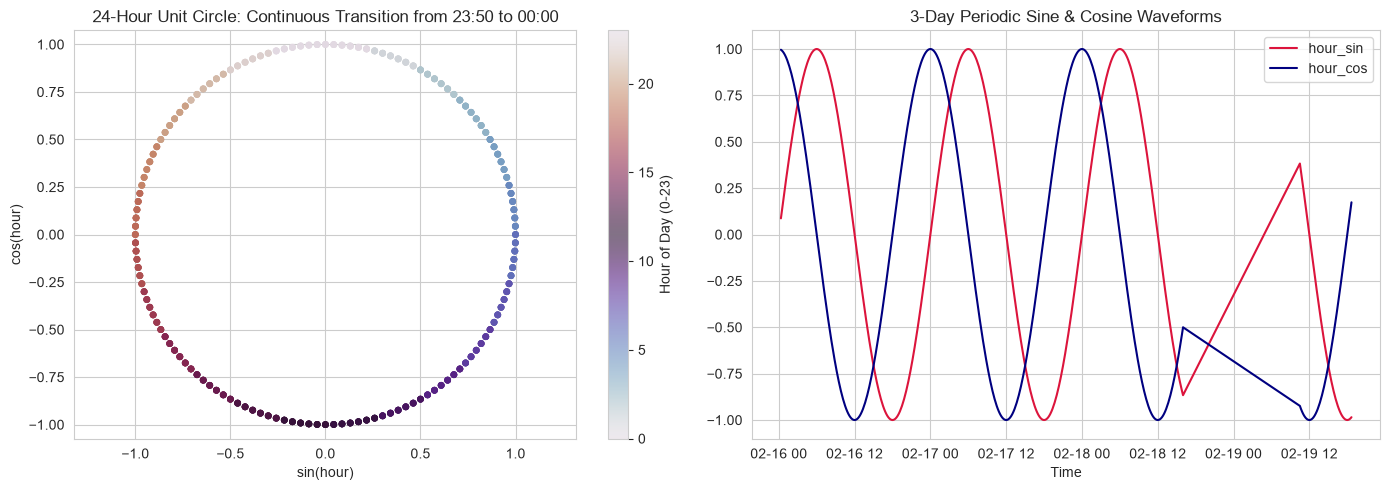

In [3]:
# Extract calendar components
hour = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
dayofweek = df["timestamp"].dt.dayofweek
month = df["timestamp"].dt.month
dayofyear = df["timestamp"].dt.dayofyear

# Cyclical trigonometric transforms
df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7.0)
df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7.0)

df["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12.0)
df["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12.0)

df["dayofyear_sin"] = np.sin(2 * np.pi * (dayofyear - 1) / 365.25)
df["dayofyear_cos"] = np.cos(2 * np.pi * (dayofyear - 1) / 365.25)

# Keep standard calendar integers for grouping and analysis
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["weekend"] = (dayofweek >= 5).astype(int)

# Visualization of the cyclical hour representation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
scatter = ax[0].scatter(df["hour_sin"].iloc[:144*7], df["hour_cos"].iloc[:144*7], 
                        c=df["hour"].iloc[:144*7], cmap="twilight", alpha=0.6, s=15)
fig.colorbar(scatter, ax=ax[0], label="Hour of Day (0-23)")
ax[0].set_title("24-Hour Unit Circle: Continuous Transition from 23:50 to 00:00")
ax[0].set_xlabel("sin(hour)")
ax[0].set_ylabel("cos(hour)")
ax[0].axis("equal")

ax[1].plot(df["timestamp"].iloc[:144*3], df["hour_sin"].iloc[:144*3], label="hour_sin", color="crimson")
ax[1].plot(df["timestamp"].iloc[:144*3], df["hour_cos"].iloc[:144*3], label="hour_cos", color="navy")
ax[1].set_title("3-Day Periodic Sine & Cosine Waveforms")
ax[1].set_xlabel("Time")
ax[1].legend()
plt.tight_layout()
plt.show()

## 5. University Calendar & BMS Operating Schedule Features

University energy demand is strictly regulated by institutional timetables. In our target BMS environment:
- **Class Hours (`is_class_hour`):** 08:00 to 18:00 on weekdays, corresponding to scheduled classes, HVAC chillers operating at nominal load, and full lighting.
- **Evening Study (`is_evening_study`):** 18:00 to 22:00, when lecture halls shut down but the library and central study zones remain active.
- **Night Idle (`is_night`):** 22:00 to 06:00, characterized by baseline parasitic loads (servers, emergency lighting, standby refrigeration).
- **Exam Periods (`is_exam_month`):** Months 4, 5, 11, and 12 (typical Indian semester exam windows: April/May and Nov/Dec). During exams, library occupancy surges to capacity and operates extended hours.
- **Vacation Periods (`is_vacation_month`):** Months 6 and 7 (summer recess), when student occupancy drops dramatically.

In [4]:
# BMS schedule flags
df["is_class_hour"] = ((df["hour"] >= 8) & (df["hour"] < 18) & (df["weekend"] == 0)).astype(int)
df["is_evening_study"] = ((df["hour"] >= 18) & (df["hour"] < 22)).astype(int)
df["is_night"] = ((df["hour"] < 6) | (df["hour"] >= 22)).astype(int)

# Academic calendar periods
df["is_exam_month"] = df["month"].isin([4, 5, 11, 12]).astype(int)
df["is_vacation_month"] = df["month"].isin([6, 7]).astype(int)

# Verify profile
bms_profile = df.groupby(["is_class_hour", "is_exam_month"])["power"].mean().unstack()
bms_profile.columns = ["Regular Month (W)", "Exam Month (W)"]
bms_profile.index = ["Off-Hours / Weekend", "Class Hours (Mon-Fri 8-18)"]
print("Mean Power Consumption (Watts) by Operational Context:")
display(bms_profile)

Mean Power Consumption (Watts) by Operational Context:


,Regular Month (W),Exam Month (W)
Off-Hours / Weekend,8383.243147,7589.566801
Class Hours (Mon-Fri 8-18),15574.307991,12971.741271


## 6. Occupancy Dynamics & Estimated BMS Zone Activation

Occupancy telemetry directly dictates variable electrical loads (lighting circuits, workstation plug-loads, and air handling units).

We engineer:
1. **Occupancy Moving Average (`occupancy_roll_mean_6`):** 6 steps (1 hour) rolling average to smooth transient doorway beam interruptions.
2. **Occupancy Velocity (`occupancy_diff_1`):** Rate of change ($\Delta \text{people} / 10\text{min}$), identifying arrival surges (e.g. 08:30 morning peak) and departures.
3. **Estimated Active Zones (`rooms_occupied_est`):** In a 7-floor campus building, HVAC dampers and smart lighting activate per-zone. Assuming an average zone capacity of ~30 students, we estimate the number of active zones ($0$ to $10$).

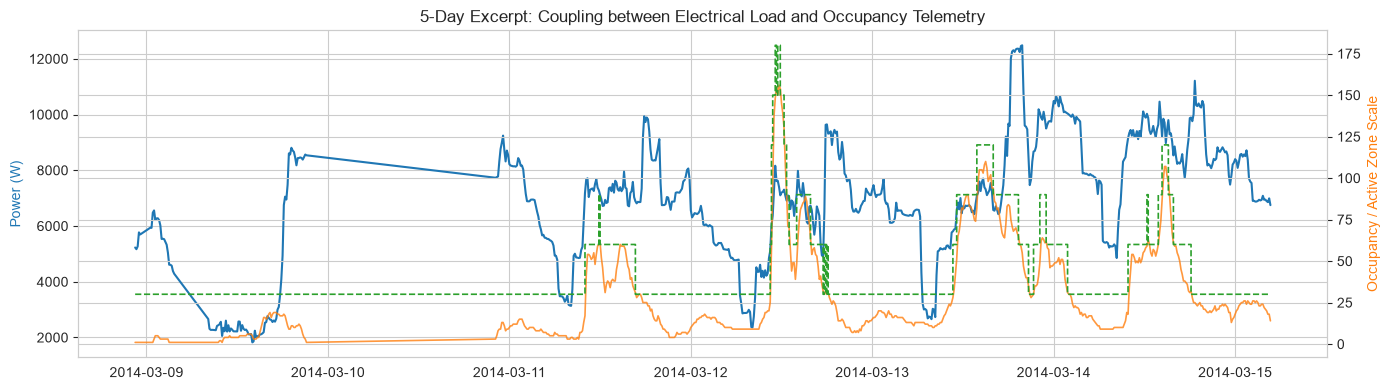

In [5]:
# 1-hour smoothed occupancy
df["occupancy_roll_mean_6"] = df["occupancy_count"].rolling(window=6, min_periods=1).mean()

# Occupancy rate of change
df["occupancy_diff_1"] = df["occupancy_count"].diff().fillna(0)

# Proxy for active BMS zones (assuming 30 people per active floor/room zone)
df["rooms_occupied_est"] = np.ceil(df["occupancy_count"] / 30.0).clip(lower=0, upper=10).astype(int)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

sample_slice = slice(144 * 20, 144 * 25)  # 5-day sample
ax1.plot(df["timestamp"].iloc[sample_slice], df["power"].iloc[sample_slice], color="tab:blue", label="Power (W)", lw=1.5)
ax2.plot(df["timestamp"].iloc[sample_slice], df["occupancy_count"].iloc[sample_slice], color="tab:orange", label="Occupancy Count", lw=1.2, alpha=0.8)
ax2.step(df["timestamp"].iloc[sample_slice], df["rooms_occupied_est"].iloc[sample_slice] * 30, color="tab:green", label="Estimated Active Zones (x30)", lw=1.2, linestyle="--")

ax1.set_ylabel("Power (W)", color="tab:blue")
ax2.set_ylabel("Occupancy / Active Zone Scale", color="tab:orange")
ax1.set_title("5-Day Excerpt: Coupling between Electrical Load and Occupancy Telemetry")
plt.tight_layout()
plt.show()

## 7. Gap-Aware Autoregressive Lags & Rolling Volatility

Real-world IoT meter streams experience transmission drops. In this dataset, there are **1,124 time gaps** exceeding 10 minutes. A naive `shift(144)` across a gap would mislabel data from days prior as "yesterday."

We enforce strict gap-awareness:
- Compute step-wise time delta: $\Delta t = \text{timestamp}_i - \text{timestamp}_{i-1}$.
- Invalidate lags with `NaN` if any $\Delta t > 10\text{ min}$ occurs within the lookback window.
- **Leakage Prevention:** All rolling statistics over the past 24 hours (mean, std, min, max) operate on `power.shift(1)` so that the current timestep $t$ is strictly preserved as the input point without contaminating historical aggregates.

In [6]:
df["time_diff"] = df["timestamp"].diff().dt.total_seconds() / 60.0

# 1. Gap-aware historical lags
for lag in [144, 288, 1008]:
    naive_shift = df["power"].shift(lag)
    max_gap_in_window = df["time_diff"].rolling(window=lag, min_periods=1).max()
    df[f"power_lag_{lag}"] = naive_shift.where(max_gap_in_window <= 10.0, np.nan)

# Gap-aware occupancy lag (same time yesterday)
naive_occ_shift = df["occupancy_count"].shift(144)
max_gap_occ = df["time_diff"].rolling(window=144, min_periods=1).max()
df["occupancy_lag_144"] = naive_occ_shift.where(max_gap_occ <= 10.0, np.nan)

# 2. Rolling statistics over past 24 hours (144 steps) - shift(1) avoids leaking current t
power_hist = df["power"].shift(1)
max_gap_24h = df["time_diff"].rolling(window=144, min_periods=1).max()
clean_power_hist = power_hist.where(max_gap_24h <= 10.0, np.nan)

df["power_roll_mean_144"] = clean_power_hist.rolling(window=144, min_periods=144).mean()
df["power_roll_std_144"] = clean_power_hist.rolling(window=144, min_periods=144).std()
df["power_roll_min_144"] = clean_power_hist.rolling(window=144, min_periods=144).min()
df["power_roll_max_144"] = clean_power_hist.rolling(window=144, min_periods=144).max()

print("Engineered Lags and Rolling Statistics:")
for col in ["power_lag_144", "power_lag_288", "power_lag_1008", "occupancy_lag_144", 
            "power_roll_mean_144", "power_roll_std_144", "power_roll_min_144", "power_roll_max_144"]:
    valid_count = df[col].notnull().sum()
    print(f"  {col:<22}: {valid_count:>6,} valid readings ({valid_count/len(df):.1%})")

Engineered Lags and Rolling Statistics:
  power_lag_144         : 84,136 valid readings (70.8%)
  power_lag_288         : 71,021 valid readings (59.8%)
  power_lag_1008        : 41,392 valid readings (34.8%)
  occupancy_lag_144     : 84,136 valid readings (70.8%)
  power_roll_mean_144   : 71,083 valid readings (59.8%)
  power_roll_std_144    : 71,083 valid readings (59.8%)
  power_roll_min_144    : 71,083 valid readings (59.8%)
  power_roll_max_144    : 71,083 valid readings (59.8%)


## 8. Target Construction (24-Hour Horizon)

The forecasting objective is predicting total building power consumption exactly 24 hours into the future:
$$\text{target}_t = \text{power}_{t + 144}$$

In [7]:
df["target"] = df["power"].shift(-144)
print(f"Target defined: power shifted -144 steps (24h ahead).")
print(f"Null target rows at series tail: {df['target'].isnull().sum()} (expected 144)")

Target defined: power shifted -144 steps (24h ahead).
Null target rows at series tail: 144 (expected 144)


## 9. Incomplete Row Cleansing

Rows with `NaN` values—originating from the initial warm-up history (7-day lookback for lag 1008), sensor gaps, and terminal target steps—are dropped. This aligns exactly with the benchmark row count from notebooks 02-04.

In [8]:
rows_raw = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_clean = len(df_clean)

print(f"Total rows before cleansing: {rows_raw:,}")
print(f"Clean continuous rows:       {rows_clean:,}")
print(f"Dropped rows (gaps/warmup):  {rows_raw - rows_clean:,} ({(rows_raw - rows_clean)/rows_raw:.1%})")
assert rows_clean == 41248, f"Row count mismatch! Expected 41,248, got {rows_clean:,}"
print("VERIFIED: Row count matches notebooks 02, 03, and 04 exactly (41,248 rows).")

Total rows before cleansing: 118,776
Clean continuous rows:       41,248
Dropped rows (gaps/warmup):  77,528 (65.3%)
VERIFIED: Row count matches notebooks 02, 03, and 04 exactly (41,248 rows).


## 10. Train/Test Chronological Split Verification

We enforce the identical **70% train / 30% test chronological split**:
- **Train Set:** First 28,873 rows (Feb 2014 to Nov 2016)
- **Test Set:** Final 12,375 rows (Nov 2016 to Nov 2017)

Preserving the identical chronological boundary guarantees zero lookahead leakage and ensures all benchmarked architectures (tree-based and deep learning) are evaluated on identical test intervals.

In [9]:
split_idx = int(len(df_clean) * 0.7)
train_df = df_clean.iloc[:split_idx]
test_df = df_clean.iloc[split_idx:]

print(f"Train split: {len(train_df):,} rows ({len(train_df)/len(df_clean):.1%}) | {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Test split:  {len(test_df):,} rows ({len(test_df)/len(df_clean):.1%}) | {test_df['timestamp'].min()} to {test_df['timestamp'].max()}")

Train split: 28,873 rows (70.0%) | 2014-02-26 10:30:00+05:30 to 2016-11-20 12:50:00+05:30
Test split:  12,375 rows (30.0%) | 2016-11-20 13:00:00+05:30 to 2017-11-02 23:50:00+05:30


## 11. Feature Correlation & Target Relationship Analysis

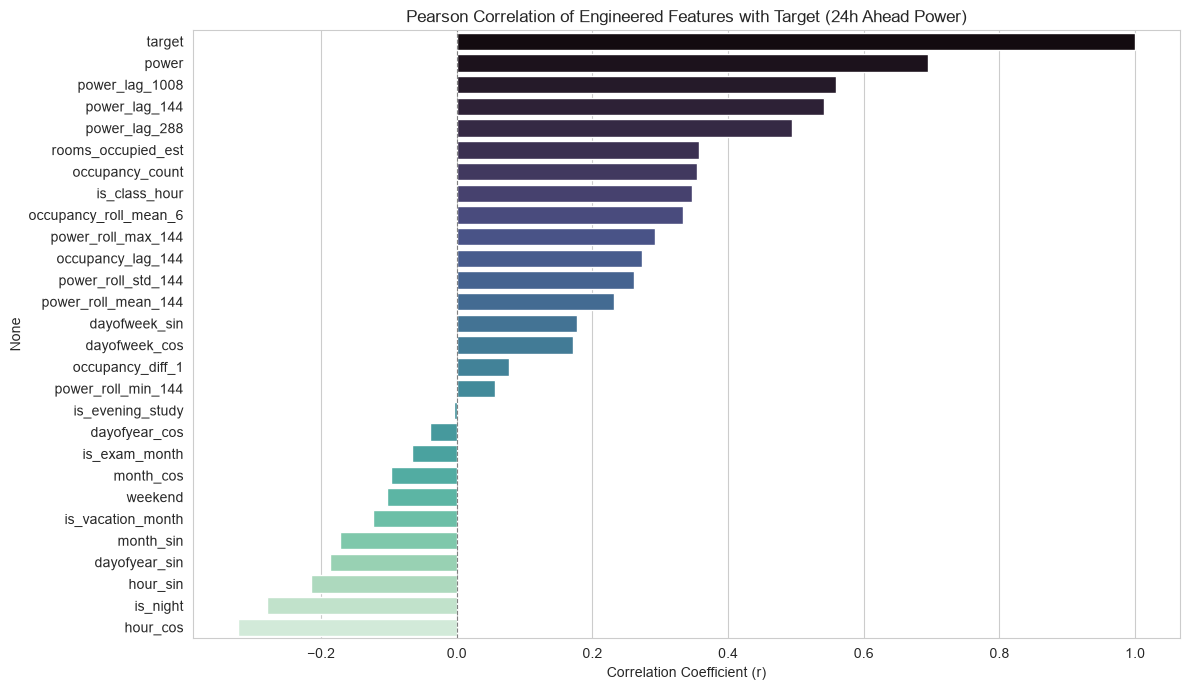

In [10]:
FEATURE_COLUMNS = [
    # Baseline power & occupancy
    "power", "occupancy_count", "occupancy_roll_mean_6", "occupancy_diff_1", "rooms_occupied_est",
    # Cyclical temporal
    "hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month_sin", "month_cos", "dayofyear_sin", "dayofyear_cos",
    # BMS schedule flags
    "weekend", "is_class_hour", "is_evening_study", "is_night", "is_exam_month", "is_vacation_month",
    # Autoregressive lags & rolling stats
    "power_lag_144", "power_lag_288", "power_lag_1008", "occupancy_lag_144",
    "power_roll_mean_144", "power_roll_std_144", "power_roll_min_144", "power_roll_max_144"
]

corr = df_clean[FEATURE_COLUMNS + ["target"]].corr()["target"].sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=corr.values, y=corr.index, palette="mako")
plt.title("Pearson Correlation of Engineered Features with Target (24h Ahead Power)")
plt.xlabel("Correlation Coefficient (r)")
plt.axvline(0, color="gray", linestyle="--", lw=0.8)
plt.tight_layout()
plt.show()

## 12. Export Engineered Feature Matrix

We save `library_featured_v2.csv` for consumption by the PyTorch deep learning models (MLP, LSTM, TCN, Transformer).

In [11]:
# Save dataset to current directory and parent directory if applicable
output_paths = ["library_featured_v2.csv", "../library_featured_v2.csv"]
saved_paths = []

for out_path in output_paths:
    parent = os.path.dirname(out_path)
    if parent == "" or os.path.exists(parent):
        df_clean.to_csv(out_path, index=False)
        saved_paths.append(out_path)

print(f"SUCCESS: Feature matrix exported to: {saved_paths}")
print(f"Exported Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Feature set size: {len(FEATURE_COLUMNS)} input features + target")

SUCCESS: Feature matrix exported to: ['library_featured_v2.csv', '../library_featured_v2.csv']
Exported Shape: 41,248 rows x 37 columns
Feature set size: 27 input features + target
